# Chapter 13 - Deploying scikit-learn Models in Production
## Saving, Loading, and Using Models in Real Applications

## Objective
Learn the basic workflow for deploying machine learning models after training.

## Theory Introduction
Deployment means moving a trained model into a real environment where it can make predictions on new incoming data. Common steps include preprocessing consistency, saving the model, loading it later, and serving predictions through apps or APIs.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
plt.style.use('ggplot')

## 1. Train Production Pipeline

In [ ]:
data=load_iris()
X,y=data.data,data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)
pipe=Pipeline([('scaler',StandardScaler()),('model',RandomForestClassifier(n_estimators=200,random_state=42))])
pipe.fit(X_train,y_train)
pred=pipe.predict(X_test)
print('Test Accuracy:', round(accuracy_score(y_test,pred),4))

Test Accuracy: 0.9211


Using a pipeline ensures preprocessing and model steps stay consistent in production.

## 2. Save Model

In [ ]:
joblib.dump(pipe,'iris_model.pkl')

['iris_model.pkl']

## 3. Load Model

In [ ]:
loaded_model = joblib.load('iris_model.pkl')

## 4. Predict New Samples

In [ ]:
new_samples = np.array([[5.1,3.5,1.4,0.2],[6.3,3.3,6.0,2.5],[5.9,3.0,4.2,1.5]])
new_pred = loaded_model.predict(new_samples)
print('Predicted Classes:', new_pred)

Predicted Classes: [0 2 1]


## 5. Prediction Distribution

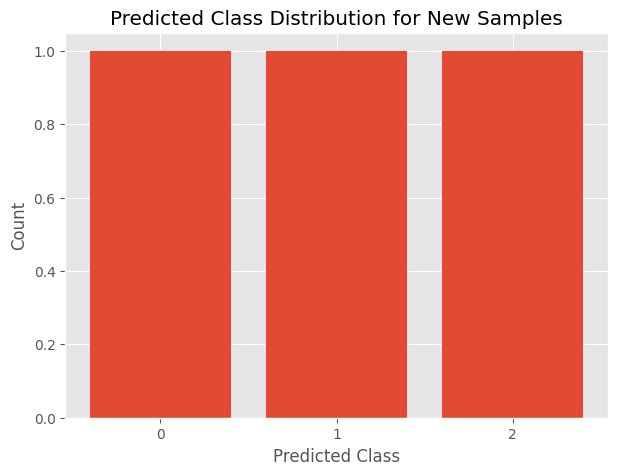

In [ ]:
unique, counts = np.unique(new_pred, return_counts=True)
plt.figure(figsize=(7,5))
plt.bar(unique.astype(str), counts)
plt.title('Predicted Class Distribution for New Samples')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.show()

**Description:** This chart summarizes predictions for incoming unseen samples.

## 6. Deployment Workflow Diagram

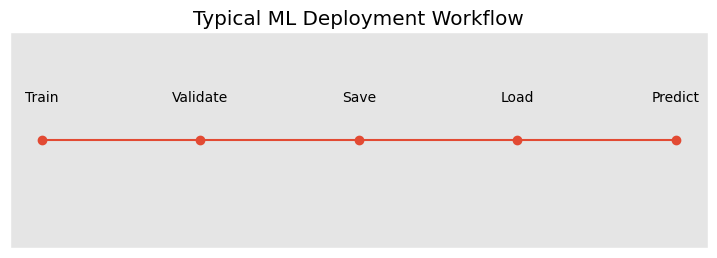

In [ ]:
steps=['Train','Validate','Save','Load','Predict']
vals=[1,1,1,1,1]
plt.figure(figsize=(9,2.8))
plt.plot(range(len(steps)), vals, marker='o')
for i,s in enumerate(steps):
    plt.text(i,1.02,s,ha='center')
plt.yticks([])
plt.xticks([])
plt.title('Typical ML Deployment Workflow')
plt.show()

**Description:** A deployed model usually follows this lifecycle from training to serving predictions.

## Important Theory Concepts
- Serialization with joblib
- Pipeline consistency
- Inference vs training
- Batch prediction vs real-time prediction
- Monitoring model drift
- Retraining when data changes

## Interpretation of Results
Strong test accuracy before deployment is important, but production success also depends on monitoring, latency, and data quality.

## Summary
Deployment is the bridge between machine learning experiments and real business value. Saving a pipeline and reusing it safely is a key first step.

## Conclusion
A good model is useful only when it can be reliably used on new data in production environments.